In [9]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
from typing import Union

def get_prices(
    ticker: Union[str, list[str]],
    start: Union[str, datetime, None] = None,
    end: Union[str, datetime, None] = None,
    lookback_days: int = 365,
    price_col: str = None,
    auto_adjust: bool = True,
) -> pd.DataFrame:
    """
    Fetch daily historical stock prices using yfinance.

    Args:
        ticker:        Single ticker symbol (e.g. "AAPL") or a list of symbols.
        start:         Start date as "YYYY-MM-DD" string or datetime. If None,
                       defaults to `lookback_days` before `end`.
        end:           End date as "YYYY-MM-DD" string or datetime. Defaults to today.
        lookback_days: Number of calendar days to look back when `start` is None.
                       Ignored if `start` is provided. Default: 365.
        price_col:     Which OHLCV column to return when a single price series is
                       needed. One of: "Open", "High", "Low", "Close", "Volume".
                       Set to None to return all columns. Default: "Close".
        auto_adjust:   Adjust prices for splits and dividends. Default: True.

    Returns:
        pd.DataFrame with a DatetimeIndex (timezone-naive, daily frequency).
        - Single ticker  → columns are OHLCV fields (or just `price_col`).
        - Multiple tickers → MultiIndex columns (field, ticker) or just
          (ticker,) when `price_col` is specified.

    Raises:
        ValueError: If no data is returned for the requested ticker(s) / range.

    Examples:
        # Single ticker, last 252 trading days of close prices
        prices = get_daily_prices("AAPL", lookback_days=252)

        # Multiple tickers, custom date range, all OHLCV columns
        prices = get_daily_prices(
            ["AAPL", "MSFT", "TSLA"],
            start="2022-01-01",
            end="2024-01-01",
            price_col=None,
        )

        # Feed close prices directly into a volatility calculation
        log_returns = np.log(prices / prices.shift(1)).dropna()
    """

    if end is None:
        end = datetime.today()

    if isinstance(end, str):
        end = datetime.strptime(end, "%Y-%m-%d")

    if start is None:
        start = end - timedelta(days=lookback_days)

    # yfinance `end` is exclusive, so add one day to include the end date
    end_exclusive = end + timedelta(days=1)

    tickers = [ticker] if isinstance(ticker, str) else ticker

    raw: pd.DataFrame = yf.download(
        tickers=tickers,
        start=start.strftime("%Y-%m-%d"),
        end=end_exclusive.strftime("%Y-%m-%d"),
        auto_adjust=auto_adjust,
        progress=False,
        multi_level_index=len(tickers) > 1,  # flat cols for single ticker
    )

    if raw.empty:
        raise ValueError(
            f"No data returned for {ticker} between {start.date()} and {end.date()}. "
            "Check that the ticker symbol is valid and the date range contains trading days."
        )
    
    raw.index = raw.index.tz_localize(None) if raw.index.tz is not None else raw.index

    # Only narrow columns if caller explicitly requests a single column
    if price_col is not None:
        if len(tickers) == 1:
            raw = raw[[price_col]]
        else:
            raw = raw[price_col]

    return raw

In [10]:
from datetime import datetime
df = get_prices(ticker=["AAPL", "TSLA", "NVDA", "MSFT", "AMZN", "META", "GOOG"], start=datetime.today() - timedelta(days=365 * 10))
print(df.head())
print(df.info())

Price           Close                                                         \
Ticker           AAPL       AMZN       GOOG        META       MSFT      NVDA   
Date                                                                           
2016-03-29  24.387419  29.693001  36.935257  115.235687  48.138737  0.866352   
2016-03-30  24.813198  29.934500  37.220917  113.806900  48.437897  0.875409   
2016-03-31  24.684107  29.681999  36.944191  113.211571  48.596264  0.872227   
2016-04-01  24.910591  29.924999  37.190170  115.156311  48.895439  0.884956   
2016-04-04  25.166498  29.659500  36.961052  111.673653  48.772259  0.876388   

Price                       High                        ...       Open  \
Ticker           TSLA       AAPL       AMZN       GOOG  ...       MSFT   
Date                                                    ...              
2016-03-29  15.342000  24.412332  29.792500  37.058248  ...  47.214854   
2016-03-30  15.126000  25.007971  30.162001  37.585424  ...  48

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from arch import arch_model

def add_garch_feature(df: pd.DataFrame):
    """
        Garch Volatility Prediction
    """

    df = df.copy()

    returns = df["log_return"] * 100
    returns = returns.dropna()

    garch = arch_model(returns, vol='Garch', p=1, q=1)
    res = garch.fit(disp="off")

    garch_vol = res.conditional_volatility

    # Align index properly
    df["garch_vol"] = np.nan
    df.loc[garch_vol.index, "garch_vol"] = garch_vol.values

    df["garch_vol"] = df["garch_vol"].shift(1)

    return df

def compute_features(df: pd.DataFrame, price_col: str = "Close") -> pd.DataFrame:
    """
        From price series compute engineered features from OHLCV data.
    """

    df = df.copy()

    df["log_return"] = np.log(df[price_col] / df[price_col].shift(1))

    df["log_volume_change"] = np.log((df["Volume"] + 1) / (df["Volume"].shift(1) + 1)) # avoiding log 0 issues

    df["log_trading_range"] = np.log(df["High"]/df["Low"])
    df["close_open_return"] = np.log(df["Close"]/df["Open"])

    # Volatility features
    trading_days = 252
    df["realized_vol_5d"] = df["log_return"].rolling(5).std() * np.sqrt(trading_days)
    df["realized_vol_21d"] = df["log_return"].rolling(21).std() * np.sqrt(trading_days)
    df["realized_vol_63d"] = df["log_return"].rolling(63).std() * np.sqrt(trading_days)

    # Momentum Features
    df["ma_5"] = df["Close"].rolling(5).mean()
    df["ma_21"] = df["Close"].rolling(21).mean()
    df["ma_ratio"] = df["ma_5"] / df["ma_21"] #trend signal

    df["vol_change"] = df["realized_vol_21d"].pct_change()

    df = add_garch_feature(df)
    df["garch_vol"] = df["garch_vol"]


    df["daily_vol"] = df["log_return"].abs()

    df.dropna(inplace=True)

    return df

def build_sequences(
        df: pd.DataFrame,
        feature_cols: list[str],
        target_col: str,
        lookback: int = 63,
        horizons: list[int] = [30, 60, 90]

) -> tuple[np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
    
    """
    Build (X, y) sequences for multi-horizon vol forecasting.

    X shape: (n_samples, lookback, n_features)
    y shape: (n_samples, len(horizons))  — one col per horizon

    Returns X, y, feature_scaler, target_scaler
    """
    
    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    features = df[feature_cols].copy()

    # getting rid of outliers
    features = features.clip(
        lower=features.quantile(0.01),
        upper = features.quantile(0.99),
        axis=1
    )

    features_scaled = feature_scaler.fit_transform(features.values)

    raw_targets = df[target_col].values

    max_horizon = max(horizons)
    X, y = [], []

    for i in range(lookback, len(features_scaled) - max_horizon):

        start_X = i - lookback
        end_X = i

        past_window = features_scaled[start_X:end_X]

        future_targets = []

        for h in horizons:
            start_y = i
            end_y = i + h

            future_avg = np.mean(raw_targets[start_y:end_y]) 
            future_targets.append(float(future_avg))
        
        X.append(past_window)
        y.append(future_targets)

    
    X = np.array(X)
    y = np.array(y)

    y = target_scaler.fit_transform(y)

    
    return X, y, feature_scaler, target_scaler

In [12]:
def compute_features_multi(df: pd.DataFrame) -> pd.DataFrame:
    """ Compute's features for multiindex dataframes"""

    tickers = df.columns.get_level_values(1).unique()
    results = {}
    for ticker in tickers:
        ticker_df = df.xs(ticker, axis=1, level=1)
        results[ticker] = compute_features(ticker_df)
    return pd.concat(results, names=["ticker"])


In [13]:
computed_features_df = compute_features_multi(df)
print(computed_features_df.head())

Price                  Close       High        Low       Open     Volume  \
ticker Date                                                                
AAPL   2016-06-27  20.972179  21.202318  20.849135  21.190924  181958400   
       2016-06-28  21.325356  21.341307  20.994960  21.168134  161779600   
       2016-06-29  21.509933  21.544113  21.334481  21.411954  146124000   
       2016-06-30  21.783358  21.822093  21.487141  21.519042  143345600   
       2016-07-01  21.849436  21.981595  21.721835  21.758292  104106000   

Price              log_return  log_volume_change  log_trading_range  \
ticker Date                                                           
AAPL   2016-06-27   -0.014668          -0.504148           0.016798   
       2016-06-28    0.016700          -0.117543           0.016362   
       2016-06-29    0.008618          -0.101779           0.009778   
       2016-06-30    0.012631          -0.019197           0.015468   
       2016-07-01    0.003029          -0

In [14]:
computed_features_df.info()

<class 'pandas.DataFrame'>
MultiIndex: 17164 entries, ('AAPL', Timestamp('2016-06-27 00:00:00')) to ('TSLA', Timestamp('2026-03-27 00:00:00'))
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Close              17164 non-null  float64
 1   High               17164 non-null  float64
 2   Low                17164 non-null  float64
 3   Open               17164 non-null  float64
 4   Volume             17164 non-null  int64  
 5   log_return         17164 non-null  float64
 6   log_volume_change  17164 non-null  float64
 7   log_trading_range  17164 non-null  float64
 8   close_open_return  17164 non-null  float64
 9   realized_vol_5d    17164 non-null  float64
 10  realized_vol_21d   17164 non-null  float64
 11  realized_vol_63d   17164 non-null  float64
 12  ma_5               17164 non-null  float64
 13  ma_21              17164 non-null  float64
 14  ma_ratio           17164 non-null  float64
 15  vol

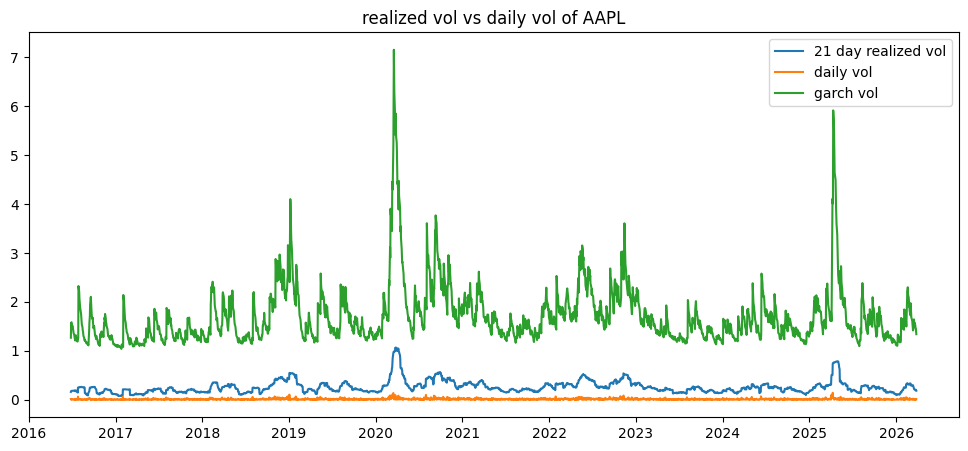

In [17]:
import matplotlib.pyplot as plt

ticker = "AAPL"
df_plot = computed_features_df.loc[ticker]

plt.figure(figsize=(12,5))
plt.plot(df_plot["realized_vol_21d"], label="21 day realized vol")
plt.plot(df_plot["daily_vol"], label= "daily vol")
plt.plot(df_plot["garch_vol"], label = "garch vol")
plt.legend()
plt.title(f"realized vol vs daily vol of {ticker}")
plt.show()